**TASK 1**

1)A 7×21 grid map of the warehouse. Each cell is either free space (.) or an obstacle (#, shelving). The environment is fully observable (the whole map is known), deterministic (a move always does what it says), static (nothing moves while the agent plans), discrete, and single-agent.

2)To move from the start cell S (row 1, col 1) to the goal cell G (row 1, col 19) along a collision-free path that never enters an obstacle cell.

3)Up, Down, Left, Right. Each action moves the vehicle one grid square.

4)The map (which cells are walls and which are free)
The current state, meaning the vehicle's (row, col) position
The goal position
The search bookkeeping

5)A goal-based agent has an explicit goal and considers the future consequences of its actions. It searches through sequences of moves and picks one that reaches G. Whereas,a simple reflex agent maps the current percept straight to an action ("if wall on the right, turn up"), with no objective and no look-ahead.


In [ ]:
"""
Goal-Based Warehouse Navigation Agent
=====================================

PROBLEM
    An autonomous vehicle must travel from S (start) to G (goal) on a 2-D
    warehouse grid without entering any obstacle cell (#).

AGENT DESIGN (goal-based)
    Environment : the warehouse grid (static, fully observable, deterministic)
    State       : the vehicle's position (row, col)
    Goal        : reach the cell marked G
    Actions     : Up, Down, Left, Right (one cell per move)
    Transition  : a move is legal only if the target cell lies inside the
                  grid and is not '#'
    Decision-making component : a search procedure that looks ahead through
                  sequences of actions to find one that reaches the goal,
                  instead of reacting only to what is next to it.

SEARCH ALGORITHM: Breadth-First Search (BFS)
    BFS keeps a FIFO queue of cells to explore and expands them in order of
    distance from the start. Intuition: it spreads outward like a ripple in
    water, so the first time the ripple touches G it has travelled the
    fewest possible steps.

    Why BFS is appropriate:
      1. Optimal  - every move costs 1, so the first path found is shortest.
      2. Complete - the grid is finite and no cell is expanded twice, so BFS
                    always terminates; if G is unreachable the queue empties
                    and we report that no path exists.
      3. Simple   - needs no heuristic. For a much larger warehouse, A*
                    (BFS guided by a distance estimate to G) would explore
                    fewer cells while still giving an optimal path.

    Complexity: O(R * C) time and memory for an R x C grid.
"""

from collections import deque

# ----------------------------------------------------------------------
# 1. The warehouse map: S start, G goal, # obstacle, . free space
# ----------------------------------------------------------------------
WAREHOUSE = """
#####################
#S....#............G#
#.##....##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################
"""

# (row change, col change, name). Order only affects tie-breaking.
ACTIONS = [(-1, 0, "Up"), (1, 0, "Down"), (0, -1, "Left"), (0, 1, "Right")]


def parse_grid(text):
    """Turn the text map into a 2-D list (one character per cell)
    and locate S and G."""
    grid = [list(line) for line in text.strip().splitlines()]

    width = len(grid[0])
    if any(len(row) != width for row in grid):
        raise ValueError("All map rows must have the same length.")

    start = goal = None
    for r, row in enumerate(grid):
        for c, cell in enumerate(row):
            if cell == "S":
                start = (r, c)
            elif cell == "G":
                goal = (r, c)

    if start is None or goal is None:
        raise ValueError("Map must contain both 'S' and 'G'.")
    return grid, start, goal


def get_neighbours(grid, pos):
    """Yield every legal next position from pos (inside grid, not an obstacle)."""
    rows, cols = len(grid), len(grid[0])
    r, c = pos
    for dr, dc, _ in ACTIONS:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] != "#":
            yield (nr, nc)


def bfs(grid, start, goal):
    """Return the shortest path [start, ..., goal] as a list of (row, col),
    or None if the goal cannot be reached."""
    frontier = deque([start])       # FIFO queue of cells waiting to be expanded
    came_from = {start: None}       # parent links; also serves as 'visited' set

    while frontier:
        current = frontier.popleft()

        if current == goal:         # goal test
            return reconstruct_path(came_from, goal)

        for nxt in get_neighbours(grid, current):
            if nxt not in came_from:
                came_from[nxt] = current
                frontier.append(nxt)

    return None                     # queue empty: no collision-free path


def reconstruct_path(came_from, goal):
    """Follow parent links from goal back to start, then reverse."""
    path, node = [], goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    return path[::-1]


def path_to_moves(path):
    """Convert consecutive positions into Up/Down/Left/Right commands."""
    lookup = {(dr, dc): name for dr, dc, name in ACTIONS}
    return [lookup[(b[0] - a[0], b[1] - a[1])] for a, b in zip(path, path[1:])]


def draw_path(grid, path):
    """Return the map as text with the route marked by '*'."""
    canvas = [row[:] for row in grid]
    for r, c in path[1:-1]:         # keep S and G visible
        canvas[r][c] = "*"
    return "\n".join("".join(row) for row in canvas)


def main():
    grid, start, goal = parse_grid(WAREHOUSE)
    print(f"Grid: {len(grid)} rows x {len(grid[0])} cols | "
          f"Start (row, col): {start} | Goal: {goal}\n")

    path = bfs(grid, start, goal)

    if path is None:
        print("No collision-free path exists from S to G.")
        return

    moves = path_to_moves(path)
    print(f"Path found in {len(moves)} moves.\n")
    print("Positions (row, col):")
    print(" -> ".join(str(p) for p in path))
    print("\nMoves:")
    print(", ".join(moves))
    print("\nRoute on the map (* = path):")
    print(draw_path(grid, path))


if __name__ == "__main__":
    main()

Grid: 7 rows x 21 cols | Start (row, col): (1, 1) | Goal: (1, 19)

Path found in 20 moves.

Positions (row, col):
(1, 1) -> (1, 2) -> (1, 3) -> (1, 4) -> (2, 4) -> (2, 5) -> (2, 6) -> (2, 7) -> (1, 7) -> (1, 8) -> (1, 9) -> (1, 10) -> (1, 11) -> (1, 12) -> (1, 13) -> (1, 14) -> (1, 15) -> (1, 16) -> (1, 17) -> (1, 18) -> (1, 19)

Moves:
Right, Right, Right, Down, Right, Right, Right, Up, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right

Route on the map (* = path):
#####################
#S***.#************G#
#.##****##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################


**TASK 3**

1)Not in my own case. My first version split the map on spaces, which breaks on your map because it has no spaces between characters. The fix was to read one character per cell. If your LLM works first time, say so; if not, note what you changed.

2)include the map verbatim and state the format, e.g. "one character per cell, no spaces".

3)BFS

4)a grid with uniform move costs and a need for a guaranteed shortest path is the textbook case for BFS

**TASK 2**
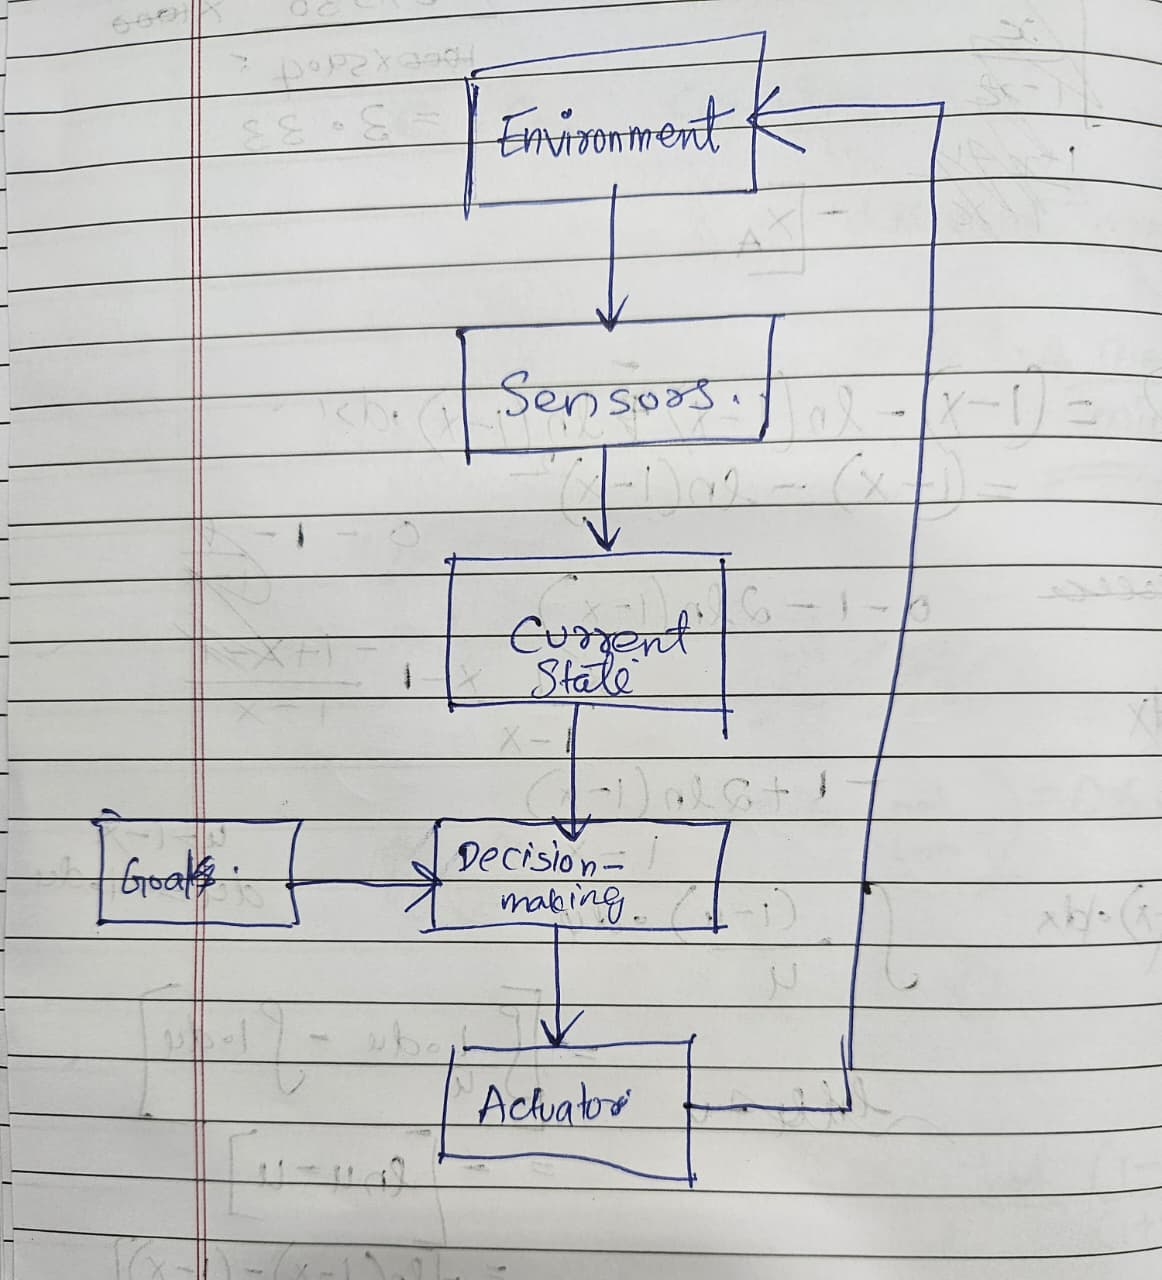
